In [28]:
# ==========================================
# CELL 1 — LOAD DAILY NIFTY SPOT SERIES FROM FUTURES FILES
# ==========================================
# The FUTIDX files have ONE ROW PER (Date, Contract) so the same date appears
# multiple times (near/mid/far month contracts). The 'Underlying Value'
# column is only populated on the front-month row and shows '-' elsewhere.
# We keep only rows with a real Underlying Value and take one per date.

import glob
import os
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== LOADING FUTURES FILES FOR DAILY SPOT SERIES ===")
fut_files = sorted(glob.glob(os.path.join(folder, "FUTIDX_NIFTY_*.csv")))
print(f"Found {len(fut_files)} futures files")

fut_list = []
for f in fut_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    fut_list.append(d)

fut = pd.concat(fut_list, ignore_index=True)

fut["Date"] = pd.to_datetime(fut["Date"].str.strip(), format="%d-%b-%Y")
fut["Underlying Value"] = pd.to_numeric(fut["Underlying Value"].astype(str).str.strip(), errors="coerce")

spot = fut.dropna(subset=["Underlying Value"]).groupby("Date")["Underlying Value"].first().reset_index()
spot = spot.rename(columns={"Underlying Value": "Spot"}).sort_values("Date").reset_index(drop=True)

print(f"✓ Built daily spot series: {len(spot):,} trading days, {spot['Date'].min().date()} to {spot['Date'].max().date()}")

=== LOADING FUTURES FILES FOR DAILY SPOT SERIES ===
Found 18 futures files
✓ Built daily spot series: 651 trading days, 2021-01-01 to 2025-06-30


In [29]:
# ==========================================
# CELL 2 — COMPUTE REALIZED VOLATILITY (THE PREDICTION TARGET)
# ==========================================
# Realized volatility = how much the index ACTUALLY moved, measured after
# the fact. This is different from IV, which is the market's GUESS of future
# movement, priced in today. We compute it as the annualized standard
# deviation of daily log returns over a forward-looking window.
#
# We compute it at two horizons matching your IV feature table: ~14 and ~30
# trading days ahead, so predictions can be compared apples-to-apples against
# ATM_IV_14D and ATM_IV_30D.

print("=== COMPUTING REALIZED VOLATILITY TARGETS ===")

spot["LogReturn"] = np.log(spot["Spot"] / spot["Spot"].shift(1))

TRADING_DAYS_PER_YEAR = 252

def forward_realized_vol(log_returns, window):
    """
    For each day t, look FORWARD `window` trading days and compute the
    annualized standard deviation of returns over that future window.
    This is what we're trying to predict using only info available at t.
    """
    n = len(log_returns)
    result = np.full(n, np.nan)
    for i in range(n - window):
        future_window = log_returns[i + 1 : i + 1 + window]
        result[i] = np.std(future_window, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    return result

log_ret_values = spot["LogReturn"].values

spot["RV_14D_fwd"] = forward_realized_vol(log_ret_values, 14)
spot["RV_30D_fwd"] = forward_realized_vol(log_ret_values, 30)

# Also compute PAST realized vol (trailing) - useful as a predictive FEATURE,
# since "how volatile was it recently" is one of the best predictors of
# near-term future volatility (volatility clustering).
spot["RV_14D_trailing"] = spot["LogReturn"].rolling(14).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
spot["RV_30D_trailing"] = spot["LogReturn"].rolling(30).std() * np.sqrt(TRADING_DAYS_PER_YEAR)

print("✓ Realized vol targets and trailing features computed.")
print()
print(spot[["Date", "Spot", "RV_14D_trailing", "RV_14D_fwd", "RV_30D_trailing", "RV_30D_fwd"]].tail(10))

=== COMPUTING REALIZED VOLATILITY TARGETS ===
✓ Realized vol targets and trailing features computed.

          Date      Spot  RV_14D_trailing  RV_14D_fwd  RV_30D_trailing  \
641 2025-06-17  24853.40         0.098262         NaN         0.159366   
642 2025-06-18  24812.05         0.097628         NaN         0.159086   
643 2025-06-19  24793.25         0.096639         NaN         0.159112   
644 2025-06-20  25112.40         0.108315         NaN         0.161811   
645 2025-06-23  24971.90         0.106333         NaN         0.159023   
646 2025-06-24  25044.35         0.106246         NaN         0.116626   
647 2025-06-25  25244.75         0.108810         NaN         0.110686   
648 2025-06-26  25549.00         0.111913         NaN         0.115047   
649 2025-06-27  25637.80         0.111711         NaN         0.106552   
650 2025-06-30  25517.05         0.114708         NaN         0.107515   

     RV_30D_fwd  
641         NaN  
642         NaN  
643         NaN  
644        

In [30]:
# ==========================================
# CELL 3 — MERGE WITH IV FEATURE TABLE + SMILE SHAPE FEATURES
# ==========================================
print("=== MERGING WITH DAILY IV FEATURE TABLE ===")

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])

df = pd.merge(iv_feat, spot, on="Date", how="inner")
print(f"✓ Merged with spot: {len(df):,} rows")

# Bring in the smile shape features from notebook 4 (level/skew/curvature
# fitted per day at 14D and 30D tenors). This is information the plain
# ATM_IV_30D / SKEW_30D columns don't fully capture - e.g. curvature says
# how strongly BOTH tails are priced up, which a single skew number can't.
smile_feat_path = os.path.join(folder, "smile_features.csv")
if os.path.exists(smile_feat_path):
    smile_feat = pd.read_csv(smile_feat_path, parse_dates=["Date"])
    smile_cols_to_use = [
        "Date", "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
        "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
        "Skew_Term_Slope", "Curv_Term_Slope",
    ]
    df = pd.merge(df, smile_feat[smile_cols_to_use], on="Date", how="left")
    n_have_smile = df["Smile_Level_30D"].notna().sum()
    print(f"✓ Merged smile features from notebook 4: {n_have_smile:,} / {len(df):,} rows have them")
    HAVE_SMILE_FEATURES = True
else:
    print("⚠️ smile_features.csv not found - run notebook 4 first to unlock smile-shape features.")
    print("   Continuing WITHOUT them for now.")
    HAVE_SMILE_FEATURES = False

# Volatility risk premium: IV minus trailing realized vol.
# This single number is a classic, well-known feature in vol forecasting -
# it tells you whether the option market is currently pricing MORE or LESS
# movement than has actually been happening recently.
df["VRP_30D"] = df["ATM_IV_30D"] - df["RV_30D_trailing"]
df["VRP_14D"] = df["ATM_IV_14D"] - df["RV_14D_trailing"]

# Term structure slope: is the market pricing more or less vol further out?
df["Term_Slope"] = df["ATM_IV_30D"] - df["ATM_IV_14D"]

print(df[["Date", "ATM_IV_30D", "RV_30D_trailing", "VRP_30D", "Term_Slope"]].tail(10))

=== MERGING WITH DAILY IV FEATURE TABLE ===
✓ Merged with spot: 651 rows
✓ Merged smile features from notebook 4: 651 / 651 rows have them
          Date  ATM_IV_30D  RV_30D_trailing   VRP_30D  Term_Slope
641 2025-06-17    0.138861         0.159366 -0.020505   -0.001727
642 2025-06-18    0.140620         0.159086 -0.018466   -0.000536
643 2025-06-19    0.137364         0.159112 -0.021748   -0.002205
644 2025-06-20    0.131182         0.161811 -0.030629    0.001693
645 2025-06-23    0.138533         0.159023 -0.020490   -0.001948
646 2025-06-24    0.132375         0.116626  0.015749   -0.001575
647 2025-06-25    0.125095         0.110686  0.014409   -0.000794
648 2025-06-26    0.119896         0.115047  0.004849   -0.002678
649 2025-06-27    0.117079         0.106552  0.010527    0.002591
650 2025-06-30    0.121933         0.107515  0.014418   -0.003088


In [31]:
# ==========================================
# CELL 4 — FEATURE ENGINEERING
# ==========================================
# All features below use ONLY information available AT or BEFORE day t.
# The target (RV_30D_fwd) uses information from AFTER day t.
# This separation is critical - mixing them causes lookahead bias, which
# makes a model look great in testing and fail completely in real use.

print("=== BUILDING FEATURE SET ===")

FEATURE_COLS = [
    "ATM_IV_30D", "PUT_IV_30D", "CALL_IV_30D", "SKEW_30D",
    "ATM_IV_14D", "PUT_IV_14D", "CALL_IV_14D", "SKEW_14D",
    "RV_14D_trailing", "RV_30D_trailing",
    "VRP_30D", "VRP_14D", "Term_Slope",
]

# Lag-1 changes: how much did each feature move since yesterday.
# Sudden jumps in IV or skew often precede continued volatility.
for col in ["ATM_IV_30D", "SKEW_30D", "Term_Slope"]:
    df[f"{col}_chg1d"] = df[col].diff(1)
    FEATURE_COLS.append(f"{col}_chg1d")

# 5-day rolling mean of ATM IV - smooths out daily noise
df["ATM_IV_30D_ma5"] = df["ATM_IV_30D"].rolling(5).mean()
FEATURE_COLS.append("ATM_IV_30D_ma5")

# Smile shape features from notebook 4 - these carry information beyond a
# single ATM IV / skew number: how strongly BOTH tails are priced (curvature),
# and how that shape differs between the 14D and 30D tenors.
if HAVE_SMILE_FEATURES:
    SMILE_FEATURE_COLS = [
        "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
        "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
        "Skew_Term_Slope", "Curv_Term_Slope",
    ]
    FEATURE_COLS.extend(SMILE_FEATURE_COLS)

TARGET_COL = "RV_30D_fwd"

model_df = df[["Date"] + FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"✓ Final modeling table: {len(model_df):,} rows, {len(FEATURE_COLS)} features")
print(f"  Target: {TARGET_COL}")
print(f"  Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

=== BUILDING FEATURE SET ===
✓ Final modeling table: 591 rows, 25 features
  Target: RV_30D_fwd
  Date range: 2021-05-11 to 2025-05-16


In [32]:
# ==========================================
# CELL 5 — TRAIN / TEST SPLIT (TIME-ORDERED, NO SHUFFLING)
# ==========================================
# For time series, NEVER randomly shuffle train/test - that leaks future
# information into training. Split by date instead: train on the past,
# test on a later, unseen period.

print("=== SPLITTING TRAIN / TEST BY DATE ===")

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows, {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test:  {len(test_df):,} rows, {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

=== SPLITTING TRAIN / TEST BY DATE ===
Train: 472 rows, 2021-05-11 to 2024-10-04
Test:  119 rows, 2024-10-07 to 2025-05-16


In [33]:
# ==========================================
# CELL 6 — BASELINES
# ==========================================
# Any real model needs to beat these simple baselines to be worth anything.

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

print("=== BASELINE MODELS ===")

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<28} MAE={mae:.4f}   RMSE={rmse:.4f}")
    return mae, rmse

# Baseline 1: naive persistence - "tomorrow's 30d realized vol = today's
# trailing 30d realized vol"
naive_pred = test_df["RV_30D_trailing"].values
report("Naive (persistence)", y_test, naive_pred)

# Baseline 2: use the market's own IV as the forecast. This is the number
# your model needs to beat to prove it adds value over just reading the
# option market.
iv_pred = test_df["ATM_IV_30D"].values
report("Market IV as forecast", y_test, iv_pred)

# Baseline 3: simple linear regression on all features
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)
report("Linear Regression", y_test, lin_pred)

=== BASELINE MODELS ===
Naive (persistence)          MAE=0.0332   RMSE=0.0421
Market IV as forecast        MAE=0.0293   RMSE=0.0373
Linear Regression            MAE=0.0395   RMSE=0.0475


(0.039522087230111726, 0.047534833192098204)

In [34]:
# ==========================================
# CELL 7 — GRADIENT BOOSTED MODEL (main model)
# ==========================================
# Gradient boosting works well here because our data is a table of daily
# numbers (not raw sequences), and it handles non-linear feature interactions
# (e.g. "skew matters more when IV is already high") without needing much
# tuning. It's a strong, standard first choice for this kind of tabular
# time-series feature set.

from sklearn.ensemble import GradientBoostingRegressor

print("=== TRAINING GRADIENT BOOSTED MODEL ===")

gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

report("Gradient Boosting", y_test, gbr_pred)

print()
print("--- Feature importance ---")
importance = pd.Series(gbr.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importance.head(10))

=== TRAINING GRADIENT BOOSTED MODEL ===
Gradient Boosting            MAE=0.0331   RMSE=0.0399

--- Feature importance ---
RV_30D_trailing    0.339481
RV_14D_trailing    0.153339
ATM_IV_30D_ma5     0.124518
CALL_IV_30D        0.089598
VRP_14D            0.060643
ATM_IV_30D         0.036131
Smile_Skew_14D     0.031736
VRP_30D            0.027719
Term_Slope         0.020832
SKEW_14D           0.019280
dtype: float64


In [35]:
# ==========================================
# CELL 7b — DID THE SMILE FEATURES ACTUALLY HELP?
# ==========================================
# Train the SAME model architecture with and without the notebook-4 smile
# shape features, on the exact same train/test split, so the comparison
# isolates the effect of those features specifically.

if HAVE_SMILE_FEATURES:
    print("=== COMPARISON: WITH vs WITHOUT SMILE SHAPE FEATURES ===")

    BASE_FEATURE_COLS = [c for c in FEATURE_COLS if c not in SMILE_FEATURE_COLS]

    gbr_base = GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42,
    )
    gbr_base.fit(train_df[BASE_FEATURE_COLS], y_train)
    base_pred = gbr_base.predict(test_df[BASE_FEATURE_COLS])

    print("Without smile shape features:")
    report("  GBM (base features only)", y_test, base_pred)
    print("With smile shape features:")
    report("  GBM (base + smile shape)", y_test, gbr_pred)
else:
    print("Skipping comparison - smile_features.csv was not found. Run notebook 4 first.")

=== COMPARISON: WITH vs WITHOUT SMILE SHAPE FEATURES ===
Without smile shape features:
  GBM (base features only)   MAE=0.0321   RMSE=0.0393
With smile shape features:
  GBM (base + smile shape)   MAE=0.0331   RMSE=0.0399


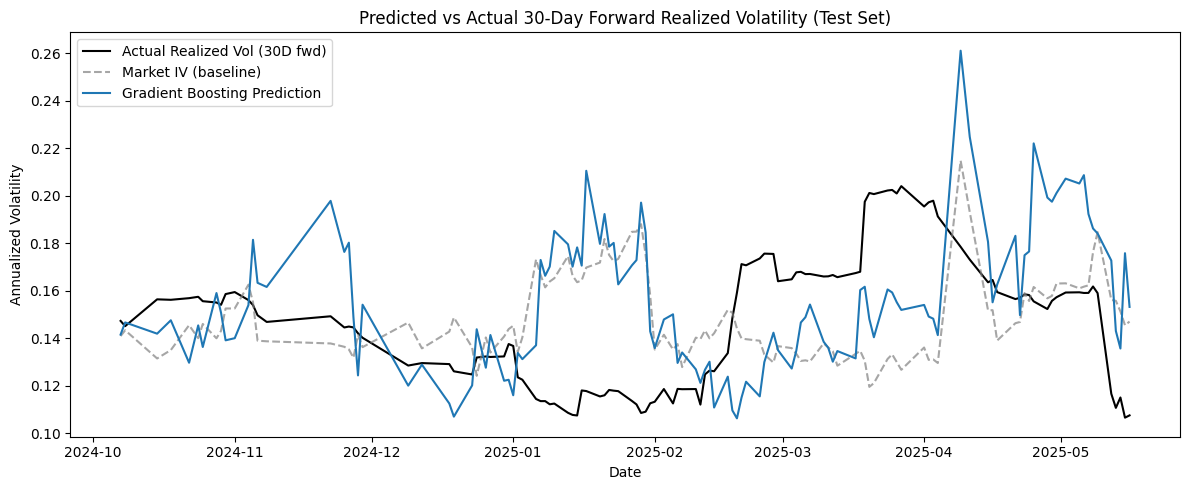

✓ If the model is useful, the blue line should track the black line
  MORE closely than the gray (market IV) line does.


In [36]:
# ==========================================
# CELL 8 — VISUALIZE: PREDICTED VS ACTUAL ON TEST SET
# ==========================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df["Date"], y_test, label="Actual Realized Vol (30D fwd)", color="black", linewidth=1.5)
ax.plot(test_df["Date"], iv_pred, label="Market IV (baseline)", color="gray", linestyle="--", alpha=0.7)
ax.plot(test_df["Date"], gbr_pred, label="Gradient Boosting Prediction", color="tab:blue")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.set_title("Predicted vs Actual 30-Day Forward Realized Volatility (Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("rv_prediction_test.png", dpi=100)
plt.show()

print("✓ If the model is useful, the blue line should track the black line")
print("  MORE closely than the gray (market IV) line does.")